# Nonlinear Economic Dispatch: Three NLP Formulations

This notebook develops three single-period economic dispatch formulations:

1. **Transmission losses only** — linear generation cost, nonlinear transmission-loss constraint.
2. **Nonlinear cost function only** — quadratic generation cost, no transmission losses.
3. **Both nonlinear cost and transmission losses** — quadratic objective and nonlinear loss constraint.

All three models use the same generator limits and demand so the effect of each nonlinearity is easy to compare. The optimization models are written in **Pyomo** and solved using **IPOPT**.

The plotting functions are intentionally independent of Pyomo: once results are stored in a `pandas.DataFrame`, the same plotting function can be reused for other cases or externally generated results.

## Define model and data

For every generator $g$:

- $P_g$ = generated power [MW]
- $P_g^{\min}$, $P_g^{\max}$ = minimum and maximum generation [MW]
- $P_D$ = total system demand [MW]

For quadratic generation costs:

$$ C_g(P_g) = a_g P_g^2 + b_gP_g + c_g $$

For transmission losses, the classical B-coefficient approximation is

$$ P_L = \sum_g\sum_h P_g B_{gh} P_h = \mathbf{P}^T B\mathbf{P}. $$

If $P_g$ is in MW, the coefficients $B_{gh}$ have units consistent with making $P_L$ come out in MW.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

pd.set_option("display.precision", 4)

In [2]:
generators = ["Coal", "Gas", "Diesel"]

demand = 350.0  # MW

gen_data = pd.DataFrame({
    "Generator": generators,
    "Pmin_MW": [50.0, 50.0, 20.0],
    "Pmax_MW": [200.0, 180.0, 150.0],

    # Linear cost coefficients for Section 1: C_g = linear_cost * P_g
    "linear_cost_per_MWh": [18.0, 22.0, 30.0],

    # Quadratic cost coefficients for Sections 2 and 3:
    # C_g(P_g) = a_g P_g^2 + b_g P_g + c_g
    "a": [0.020, 0.010, 0.005],
    "b": [10.0, 15.0, 22.0],
    "c": [100.0, 120.0, 80.0],
}).set_index("Generator")

# Symmetric B-coefficient matrix for transmission losses.
B = pd.DataFrame(
    [[8.0e-5, 1.0e-5, 0.5e-5],
     [1.0e-5, 1.0e-4, 0.8e-5],
     [0.5e-5, 0.8e-5, 1.2e-4]],
    index=generators,
    columns=generators,
)

print("Generator data:")
display(gen_data)
print(f"Demand = {demand:.1f} MW")
print("\nB-coefficient matrix:")
display(B)

Generator data:


,Pmin_MW,Pmax_MW,linear_cost_per_MWh,a,b,c
Generator,,,,,,
Coal,50.0,200.0,18.0,0.020,10.0,100.0
Gas,50.0,180.0,22.0,0.010,15.0,120.0
Diesel,20.0,150.0,30.0,0.005,22.0,80.0


Demand = 350.0 MW

B-coefficient matrix:


,Coal,Gas,Diesel
Coal,8.0000e-05,1.0000e-05,5.0000e-06
Gas,1.0000e-05,1.0000e-04,8.0000e-06
Diesel,5.0000e-06,8.0000e-06,1.2000e-04


### Reusable helper functions

`solve_model()` checks for IPOPT and solves a Pyomo model.

`results_to_dataframe()` converts a solved model into a tidy `pandas.DataFrame`. This DataFrame is the only object required by the plotting function.

`plot_dispatch_results()` is deliberately **model-independent**. You can replace `results_df` with any DataFrame containing at least:

- `Generator`
- `Power_MW`
- `Generation_Cost`

Optional columns `Pmin_MW` and `Pmax_MW` are used to show limits.

In [3]:
def solve_model(model, solver_name="ipopt", tee=False):
    """Solve a Pyomo NLP model with the requested solver."""
    solver = pyo.SolverFactory(solver_name)
    if not solver.available(exception_flag=False):
        raise RuntimeError(
            f"Solver '{solver_name}' is not available. Install IPOPT and make sure "
            "its executable is visible to your Python environment."
        )
    result = solver.solve(model, tee=tee)
    return result


def compute_B_loss(power_by_generator, B_matrix):
    """Compute P_L = P^T B P from a dict/Series of generator powers."""
    p = np.array([power_by_generator[g] for g in B_matrix.index], dtype=float)
    return float(p @ B_matrix.to_numpy(dtype=float) @ p)


def results_to_dataframe(model, gen_data, cost_type, B_matrix=None):
    """
    Convert a solved model to a tidy DataFrame.

    cost_type:
        'linear'    -> C_g = linear_cost_per_MWh * P_g
        'quadratic' -> C_g = a_g P_g^2 + b_g P_g + c_g
    """
    rows = []
    for g in model.G:
        P = pyo.value(model.P[g])

        if cost_type == "linear":
            cost = gen_data.loc[g, "linear_cost_per_MWh"] * P
            marginal_cost = gen_data.loc[g, "linear_cost_per_MWh"]
        elif cost_type == "quadratic":
            a = gen_data.loc[g, "a"]
            b = gen_data.loc[g, "b"]
            c = gen_data.loc[g, "c"]
            cost = a * P**2 + b * P + c
            marginal_cost = 2 * a * P + b
        else:
            raise ValueError("cost_type must be 'linear' or 'quadratic'.")

        rows.append({
            "Generator": g,
            "Power_MW": P,
            "Pmin_MW": gen_data.loc[g, "Pmin_MW"],
            "Pmax_MW": gen_data.loc[g, "Pmax_MW"],
            "Generation_Cost": cost,
            "Marginal_Cost": marginal_cost,
        })

    df = pd.DataFrame(rows)

    # Store system-level quantities directly in the DataFrame as repeated columns.
    # This makes the DataFrame self-contained and easy to save as CSV.
    total_generation = df["Power_MW"].sum()
    loss = 0.0
    if B_matrix is not None:
        p_series = df.set_index("Generator")["Power_MW"]
        loss = compute_B_loss(p_series, B_matrix)

    df["Demand_MW"] = demand
    df["Total_Generation_MW"] = total_generation
    df["Transmission_Loss_MW"] = loss
    df["Total_Cost"] = df["Generation_Cost"].sum()

    return df


def plot_dispatch_results(results_df, title="Economic Dispatch Results"):
    """
    Plot results from any compatible pandas DataFrame.

    Required columns:
        Generator, Power_MW, Generation_Cost

    Optional columns:
        Pmin_MW, Pmax_MW, Demand_MW, Total_Generation_MW,
        Transmission_Loss_MW, Total_Cost
    """
    required = {"Generator", "Power_MW", "Generation_Cost"}
    missing = required - set(results_df.columns)
    if missing:
        raise ValueError(f"results_df is missing required columns: {sorted(missing)}")

    df = results_df.copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- Plot 1: generator dispatch ---
    axes[0].bar(df["Generator"], df["Power_MW"])
    axes[0].set_ylabel("Power generation (MW)")
    axes[0].set_xlabel("Generator")
    axes[0].set_title("Optimal generator dispatch")
    axes[0].grid(axis="y", alpha=0.3)

    if "Pmax_MW" in df.columns:
        axes[0].scatter(df["Generator"], df["Pmax_MW"], marker="_", s=250, label="$P_g^{max}$")
    if "Pmin_MW" in df.columns:
        axes[0].scatter(df["Generator"], df["Pmin_MW"], marker="_", s=250, label="$P_g^{min}$")
    if "Pmax_MW" in df.columns or "Pmin_MW" in df.columns:
        axes[0].legend()

    # --- Plot 2: cost contribution ---
    axes[1].bar(df["Generator"], df["Generation_Cost"])
    axes[1].set_ylabel("Generation cost")
    axes[1].set_xlabel("Generator")
    axes[1].set_title("Cost contribution")
    axes[1].grid(axis="y", alpha=0.3)

    # System-level information
    demand_value = df["Demand_MW"].iloc[0] if "Demand_MW" in df else np.nan
    generation_value = (
        df["Total_Generation_MW"].iloc[0]
        if "Total_Generation_MW" in df
        else df["Power_MW"].sum()
    )
    loss_value = df["Transmission_Loss_MW"].iloc[0] if "Transmission_Loss_MW" in df else np.nan
    total_cost = df["Total_Cost"].iloc[0] if "Total_Cost" in df else df["Generation_Cost"].sum()

    summary_parts = []
    if np.isfinite(demand_value):
        summary_parts.append(f"Demand = {demand_value:.2f} MW")
    summary_parts.append(f"Generation = {generation_value:.2f} MW")
    if np.isfinite(loss_value):
        summary_parts.append(f"Loss = {loss_value:.2f} MW")
    summary_parts.append(f"Total cost = {total_cost:.2f}")

    fig.suptitle(title + "\n" + " | ".join(summary_parts), fontsize=12)
    plt.tight_layout()
    plt.show()

# Part 1. Transmission Losses Only

## Decision variables

For each generator $g$:

$$ P_g \quad \text{[MW]} $$

where $P_g$ is the power output of generator $g$.

## Fixed values

- $P_D$ = system demand
- $P_g^{\min}$ = minimum generator output
- $P_g^{\max}$ = maximum generator output
- $c_g$ = linear generation cost coefficient
- $B_{gh}$ = transmission-loss coefficients

The transmission loss is

$$ P_L = \sum_g\sum_h P_gB_{gh}P_h. $$

## Objective

Generation cost is linear:

$$ \min \; \sum_g c_g P_g $$

## Constraints

### Power balance including transmission loss

$$\sum_g P_g = P_D + \sum_g\sum_h P_gB_{gh}P_h$$

The quadratic term makes this constraint nonlinear.

### Generator limits

$$ P_g^{\min} \leq P_g \leq P_g^{\max}.$$

,Generator,Power_MW,Pmin_MW,Pmax_MW,Generation_Cost,Marginal_Cost,Demand_MW,Total_Generation_MW,Transmission_Loss_MW,Total_Cost
0,Coal,200.0000,50.0,200.0,3600.000,18.0,350.0,355.7162,5.7162,7185.756
1,Gas,135.7162,50.0,180.0,2985.756,22.0,350.0,355.7162,5.7162,7185.756
2,Diesel,20.0000,20.0,150.0,600.000,30.0,350.0,355.7162,5.7162,7185.756


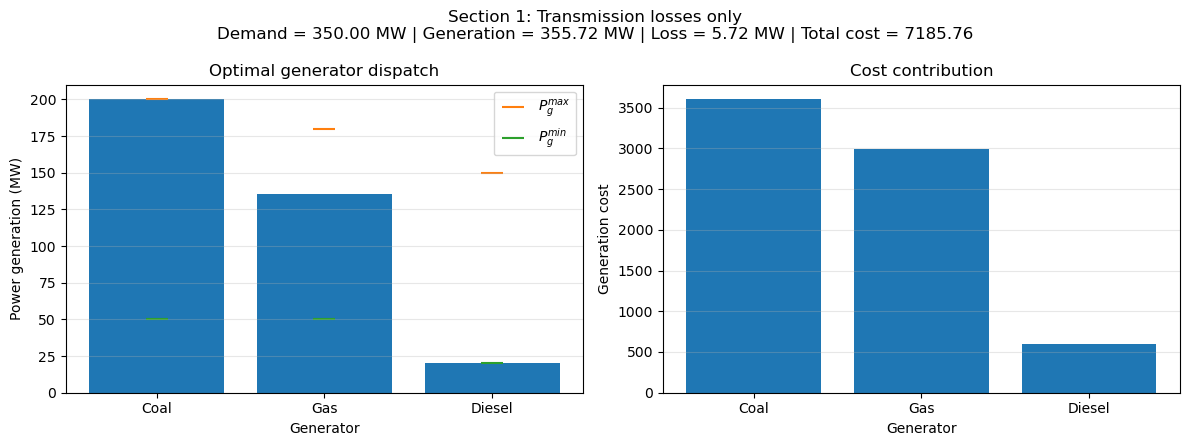

In [4]:
def build_model_losses_only(gen_data, demand, B):
    model = pyo.ConcreteModel(name="ED - Transmission Losses Only")
    model.G = pyo.Set(initialize=list(gen_data.index), ordered=True)

    model.P = pyo.Var(
        model.G,
        bounds=lambda m, g: (
            float(gen_data.loc[g, "Pmin_MW"]),
            float(gen_data.loc[g, "Pmax_MW"]),
        ),
        initialize=lambda m, g: 0.5 * (
            gen_data.loc[g, "Pmin_MW"] + gen_data.loc[g, "Pmax_MW"]
        ),
    )

    model.obj = pyo.Objective(
        expr=sum(gen_data.loc[g, "linear_cost_per_MWh"] * model.P[g] for g in model.G),
        sense=pyo.minimize,
    )

    loss_expr = sum(
        model.P[g] * float(B.loc[g, h]) * model.P[h]
        for g in model.G for h in model.G
    )

    model.power_balance = pyo.Constraint(
        expr=sum(model.P[g] for g in model.G) == demand + loss_expr
    )

    return model


model_1 = build_model_losses_only(gen_data, demand, B)
solve_model(model_1)

results_1 = results_to_dataframe(model_1, gen_data, cost_type="linear", B_matrix=B)
display(results_1)
plot_dispatch_results(results_1, "Section 1: Transmission losses only")

# Part 2. Nonlinear Cost Function Only

## Decision variables

For each generator $g$:

$$ P_g \quad \text{[MW]}. $$

## Fixed values

- $P_D$ = system demand
- $P_g^{\min}$ = minimum generator output
- $P_g^{\max}$ = maximum generator output
- $a_g,b_g,c_g$ = quadratic generation-cost coefficients

## Objective

Each generator has the quadratic cost function

$$ C_g(P_g)=a_gP_g^2+b_gP_g+c_g. $$

The objective is

$$\min \; \sum_g\left(a_gP_g^2+b_gP_g+c_g\right)$$

Its marginal cost is $ \frac{dC_g}{dP_g}=2a_gP_g+b_g. $

## Constraints

There are no transmission losses in this section, so $ \sum_gP_g=P_D $

with generator limits

$$ P_g^{\min}\leq P_g\leq P_g^{\max}. $$

Here, the nonlinearity is in the **objective**, while all constraints remain linear. With $a_g>0$, this formulation is a convex quadratic program, although a general NLP solver such as IPOPT can solve it as well.

,Generator,Power_MW,Pmin_MW,Pmax_MW,Generation_Cost,Marginal_Cost,Demand_MW,Total_Generation_MW,Transmission_Loss_MW,Total_Cost
0,Coal,193.3333,50.0,200.0,2780.8889,17.7333,350.0,350.0,0.0,5659.6667
1,Gas,136.6667,50.0,180.0,2356.7778,17.7333,350.0,350.0,0.0,5659.6667
2,Diesel,20.0000,20.0,150.0,522.0000,22.2000,350.0,350.0,0.0,5659.6667


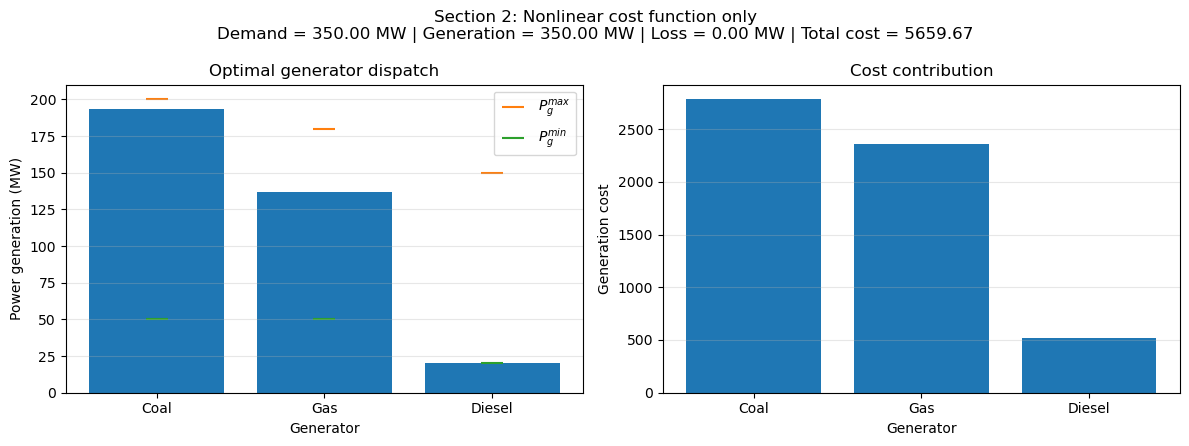

In [5]:
def build_model_quadratic_cost_only(gen_data, demand):
    model = pyo.ConcreteModel(name="ED - Quadratic Cost Only")
    model.G = pyo.Set(initialize=list(gen_data.index), ordered=True)

    model.P = pyo.Var(
        model.G,
        bounds=lambda m, g: (
            float(gen_data.loc[g, "Pmin_MW"]),
            float(gen_data.loc[g, "Pmax_MW"]),
        ),
        initialize=lambda m, g: demand / len(gen_data),
    )

    model.obj = pyo.Objective(
        expr=sum(
            gen_data.loc[g, "a"] * model.P[g]**2
            + gen_data.loc[g, "b"] * model.P[g]
            + gen_data.loc[g, "c"]
            for g in model.G
        ),
        sense=pyo.minimize,
    )

    model.power_balance = pyo.Constraint(
        expr=sum(model.P[g] for g in model.G) == demand
    )

    return model


model_2 = build_model_quadratic_cost_only(gen_data, demand)
solve_model(model_2)

results_2 = results_to_dataframe(model_2, gen_data, cost_type="quadratic", B_matrix=None)
display(results_2)
plot_dispatch_results(results_2, "Section 2: Nonlinear cost function only")

# Part 3. Nonlinear Cost Function + Transmission Losses

## Decision variables

For each generator $g$:

$$ P_g \quad \text{[MW]}. $$

## Fixed values

- $P_D$ = system demand
- $P_g^{\min}$, $P_g^{\max}$ = generator limits
- $a_g,b_g,c_g$ = quadratic cost coefficients
- $B_{gh}$ = transmission-loss coefficients

## Objective

$$ \min \; \sum_g\left(a_gP_g^2+b_gP_g+c_g\right) $$

## Constraints

Transmission losses are

$$ P_L=\sum_g\sum_hP_gB_{gh}P_h. $$

Hence, the nonlinear power balance is

$$\sum_gP_g=P_D+\sum_g\sum_hP_gB_{gh}P_h$$

and the generator limits are

$$ P_g^{\min}\leq P_g\leq P_g^{\max}. $$

This formulation has nonlinearity in **both the objective and a constraint**.

,Generator,Power_MW,Pmin_MW,Pmax_MW,Generation_Cost,Marginal_Cost,Demand_MW,Total_Generation_MW,Transmission_Loss_MW,Total_Cost
0,Coal,194.695,50.0,200.0,2805.0720,17.7878,350.0,355.7019,5.7019,5761.0061
1,Gas,141.007,50.0,180.0,2433.9341,17.8201,350.0,355.7019,5.7019,5761.0061
2,Diesel,20.000,20.0,150.0,522.0000,22.2000,350.0,355.7019,5.7019,5761.0061


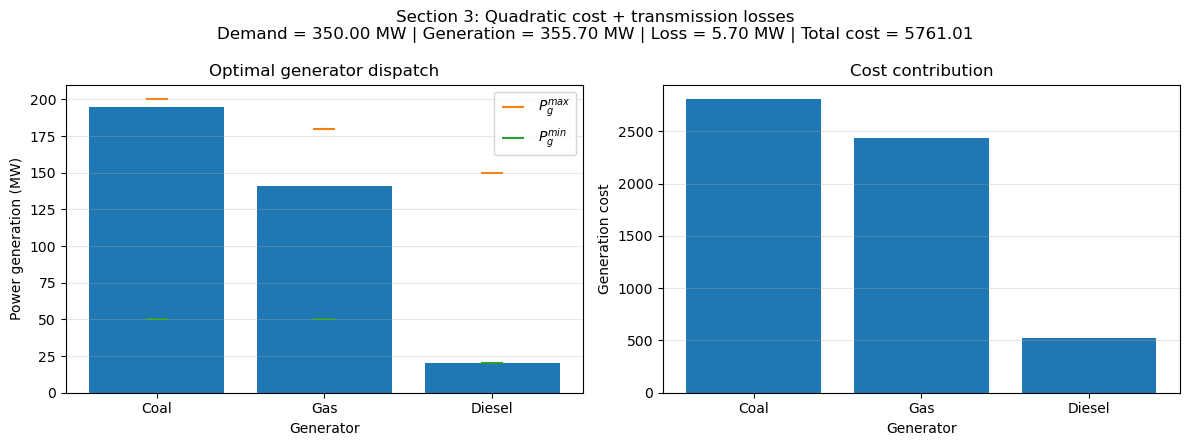

In [6]:
def build_model_both(gen_data, demand, B):
    model = pyo.ConcreteModel(name="ED - Quadratic Cost and Transmission Losses")
    model.G = pyo.Set(initialize=list(gen_data.index), ordered=True)

    model.P = pyo.Var(
        model.G,
        bounds=lambda m, g: (
            float(gen_data.loc[g, "Pmin_MW"]),
            float(gen_data.loc[g, "Pmax_MW"]),
        ),
        initialize=lambda m, g: demand / len(gen_data),
    )

    model.obj = pyo.Objective(
        expr=sum(
            gen_data.loc[g, "a"] * model.P[g]**2
            + gen_data.loc[g, "b"] * model.P[g]
            + gen_data.loc[g, "c"]
            for g in model.G
        ),
        sense=pyo.minimize,
    )

    loss_expr = sum(
        model.P[g] * float(B.loc[g, h]) * model.P[h]
        for g in model.G for h in model.G
    )

    model.power_balance = pyo.Constraint(
        expr=sum(model.P[g] for g in model.G) == demand + loss_expr
    )

    return model


model_3 = build_model_both(gen_data, demand, B)
solve_model(model_3)

results_3 = results_to_dataframe(model_3, gen_data, cost_type="quadratic", B_matrix=B)
display(results_3)
plot_dispatch_results(results_3, "Section 3: Quadratic cost + transmission losses")

## Reusing the plotting function with stored DataFrames

Because the plotter does not depend on Pyomo, you can save any result table and plot it later.

For example:

```python
results_3.to_csv("results_case_3.csv", index=False)

stored_results = pd.read_csv("results_case_3.csv")
plot_dispatch_results(stored_results, "Stored dispatch results")
```

You can also create a DataFrame manually as long as it contains the required columns.

In [7]:
# Example: collect all three result DataFrames for later comparison.
results = {
    "Losses only": results_1,
    "Quadratic cost only": results_2,
    "Both": results_3,
}

# A compact comparison table
comparison = pd.DataFrame([
    {
        "Case": name,
        "Total_Generation_MW": df["Total_Generation_MW"].iloc[0],
        "Demand_MW": df["Demand_MW"].iloc[0],
        "Transmission_Loss_MW": df["Transmission_Loss_MW"].iloc[0],
        "Total_Cost": df["Total_Cost"].iloc[0],
    }
    for name, df in results.items()
])

display(comparison)

,Case,Total_Generation_MW,Demand_MW,Transmission_Loss_MW,Total_Cost
0,Losses only,355.7162,350.0,5.7162,7185.7560
1,Quadratic cost only,350.0000,350.0,0.0000,5659.6667
2,Both,355.7019,350.0,5.7019,5761.0061


## Optional: compare generator dispatch across all three cases

This final helper is also DataFrame-based. It accepts a dictionary of result DataFrames, so it can be reused with results generated elsewhere.

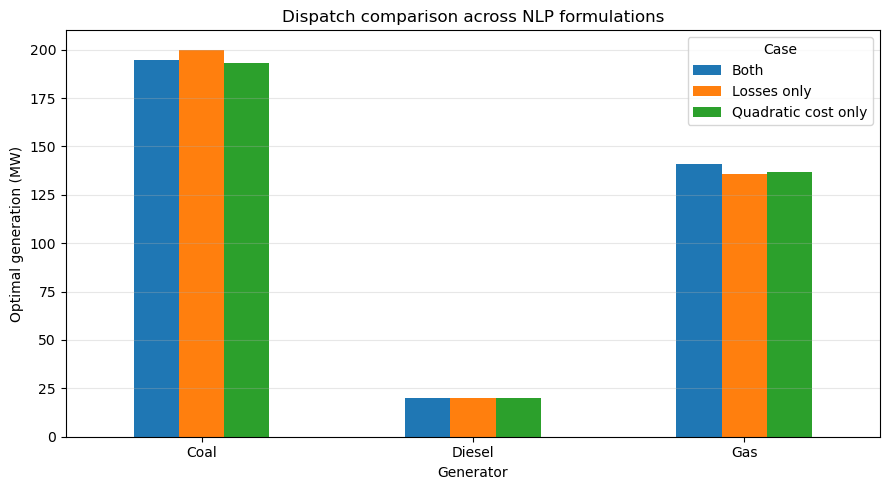

In [8]:
def plot_case_comparison(results_dict):
    records = []
    for case_name, df in results_dict.items():
        temp = df[["Generator", "Power_MW"]].copy()
        temp["Case"] = case_name
        records.append(temp)

    long_df = pd.concat(records, ignore_index=True)
    pivot = long_df.pivot(index="Generator", columns="Case", values="Power_MW")

    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_ylabel("Optimal generation (MW)")
    ax.set_xlabel("Generator")
    ax.set_title("Dispatch comparison across NLP formulations")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_case_comparison(results)